In [125]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.ndimage import rotate, zoom, shift
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil

# Analisis exploratorio

In [126]:
data_dir = Path("data/PolyMNIST/MMNIST")
plt.style.use('default')
sns.set_palette("husl")

# Primero exploramos la estructura del dataset, para saber cuales directorios hay y la cantidad
# de informacion que tiene cada directorio

# Funcion para explorar directorios
def explore_directory_structure(data_dir):
    print("Estructura del dataset")    
    structure_info = {}
    # Como sabemos que hay directorios train y test los vamos a explorar
    for split in ['train', 'test']:
        split_path = data_dir / split
        if split_path.exists():
            print(f"\n{split.upper()}:")
            structure_info[split] = {}
            
            for modality_dir in sorted(split_path.iterdir()):
                if modality_dir.is_dir():
                    modality_name = modality_dir.name
                    png_files = list(modality_dir.glob("*.png"))
                    structure_info[split][modality_name] = len(png_files)
                    print(f"  └── {modality_name}: {len(png_files)} imágenes")
        else:
            print(f"No se encontró la carpeta: {split_path}")
    
    return structure_info

# Funcion para cargar muestras de las imagenes, se puede cambiar el numero de muestras, pero solo probare con una imagen por directorio
def load_sample_images(data_dir, n_samples=1):
    samples = defaultdict(lambda: defaultdict(list))
    image_info = defaultdict(lambda: defaultdict(list))
    
    for split in ['train', 'test']:
        split_path = data_dir / split
        if not split_path.exists():
            continue
            
        print(f"\nProcesando {split}...")
        
        for modality_dir in sorted(split_path.iterdir()):
            if modality_dir.is_dir():
                modality_name = modality_dir.name
                png_files = list(modality_dir.glob("*.png"))
                
                # Tomar una muestra aleatoria
                if len(png_files) > 0:
                    sample_files = np.random.choice(png_files, 
                                                  min(n_samples, len(png_files)), 
                                                  replace=False)
                    
                    for img_path in sample_files:
                        try:
                            img = Image.open(img_path)
                            img_array = np.array(img)
                            samples[split][modality_name].append(img_array)
                            
                            # Información de la imagen
                            image_info[split][modality_name].append({
                                'filename': img_path.name,
                                'size': img.size,
                                'mode': img.mode,
                                'shape': img_array.shape,
                                'dtype': img_array.dtype,
                                'min_val': img_array.min(),
                                'max_val': img_array.max(),
                                'mean_val': img_array.mean()
                            })
                        except Exception as e:
                            print(f"Error cargando {img_path}: {e}")
                
                print(f" {modality_name}: {len(samples[split][modality_name])} muestras cargadas")
    
    return  image_info
explore_directory_structure(data_dir)
load_sample_images(data_dir)


Estructura del dataset

TRAIN:
  └── m0: 60000 imágenes
  └── m1: 60000 imágenes
  └── m2: 60000 imágenes
  └── m3: 60000 imágenes
  └── m4: 60000 imágenes

TEST:
  └── m0: 10000 imágenes
  └── m1: 10000 imágenes
  └── m2: 10000 imágenes
  └── m3: 10000 imágenes
  └── m4: 10000 imágenes

Procesando train...
 m0: 1 muestras cargadas
 m1: 1 muestras cargadas
 m2: 1 muestras cargadas
 m3: 1 muestras cargadas
 m4: 1 muestras cargadas

Procesando test...
 m0: 1 muestras cargadas
 m1: 1 muestras cargadas
 m2: 1 muestras cargadas
 m3: 1 muestras cargadas
 m4: 1 muestras cargadas


defaultdict(<function __main__.load_sample_images.<locals>.<lambda>()>,
            {'train': defaultdict(list,
                         {'m0': [{'filename': '1271.7.png',
                            'size': (28, 28),
                            'mode': 'RGB',
                            'shape': (28, 28, 3),
                            'dtype': dtype('uint8'),
                            'min_val': 5,
                            'max_val': 243,
                            'mean_val': 61.46641156462585}],
                          'm1': [{'filename': '261.7.png',
                            'size': (28, 28),
                            'mode': 'RGB',
                            'shape': (28, 28, 3),
                            'dtype': dtype('uint8'),
                            'min_val': 40,
                            'max_val': 214,
                            'mean_val': 73.30569727891157}],
                          'm2': [{'filename': '5143.9.png',
                            's

# Transformaciones a imagenes

In [127]:
# Como el lab pide de avances hasta el paso 4, por el momento solo se dejaron definidas las transformaciones que vamos  a usar para
# entrenar en la proxima entrega el modelo

# Rotación aleatoria de la imagen usando scipy
def rotate_image(self, image, angle_range=(-15, 15)):
    angle = np.random.uniform(angle_range[0], angle_range[1])
    return rotate(image, angle, reshape=False, mode='nearest')

# Zoom para la imagen
def scale_image(self, image, zoom_range=(0.9, 1.1)):
    """Escalado (zoom) de la imagen usando scipy"""
    zoom_factor = np.random.uniform(zoom_range[0], zoom_range[1])
    if len(image.shape) == 3:
        zoom_factors = [zoom_factor, zoom_factor, 1]
    else:
        zoom_factors = zoom_factor
    return zoom(image, zoom_factors, mode='nearest')

# Ruido gaussiano
def add_gaussian_noise(self, image, noise_level=0.1):
    noise = np.random.normal(0, noise_level * 255, image.shape)
    result = image.astype(np.float32) + noise
    return np.clip(result, 0, 255).astype(image.dtype)

# Blur a la imagen
def blur_image_uniform(self, image, size=3):
    kernel = np.ones((size, size)) / (size * size)
    if len(image.shape) == 3:
        result = np.zeros_like(image)
        for c in range(image.shape[2]):
            result[:, :, c] = ndimage.convolve(image[:, :, c], kernel, mode='nearest')
    else:
        result = ndimage.convolve(image, kernel, mode='nearest')
    return result

# Modelos de CNN

In [128]:
# Esto es un codigo que sirve para probar si funciona la gpu (el proyecto corre en un dockerfile con cuda)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("Configurando GPU...")
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)


GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configurando GPU...


In [129]:
combined_train = data_dir / "train_combined"
combined_test = data_dir / "test_combined"

def combinar_modalidades(origen, destino):
    destino.mkdir(exist_ok=True)
    for modalidad in sorted(origen.glob("m*")):
        for img_path in modalidad.glob("*.png"):
            label = img_path.name[0]  
            label_dir = destino / label
            label_dir.mkdir(exist_ok=True)
            shutil.copy(img_path, label_dir / img_path.name)

combinar_modalidades(data_dir / "train", combined_train)
combinar_modalidades(data_dir / "test", combined_test)
img_size = (28, 28)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    combined_train,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    combined_train,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    combined_test,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Clases encontradas: {train_generator.class_indices}")
print(f"Número de clases: {train_generator.num_classes}")

Found 48001 images belonging to 10 classes.
Found 11999 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.
Clases encontradas: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
Número de clases: 10


## Modelos CNN

In [130]:
def cnn_1():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax') # Como tenemos 10 digitos, necesitamos algo que nos permita clasificar mas clases.
    ])
    opt = keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model
    
def cnn_2():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_initializer='he_uniform', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_initializer='he_uniform'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_initializer='he_uniform'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    opt = keras.optimizers.Adam(learning_rate=0.0003)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# RNN con MLP
def build_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

mlp_model = build_mlp()
cnn1 = cnn_1()
cnn2 = cnn_2()

history_cnn1 = cnn1.fit(train_generator, validation_data=val_generator, epochs=7, callbacks=callbacks)
history_cnn2 = cnn2.fit(train_generator, validation_data=val_generator, epochs=15, callbacks=callbacks)
history_mlp = mlp_model.fit(train_generator, validation_data=val_generator, epochs=7, callbacks=callbacks)

Epoch 1/7
1501/1501 [==============================] - 17s 10ms/step - loss: 2.0505 - accuracy: 0.1801 - val_loss: 1.9106 - val_accuracy: 0.1918 - lr: 5.0000e-04
Epoch 2/7
1501/1501 [==============================] - 15s 10ms/step - loss: 1.9228 - accuracy: 0.1834 - val_loss: 1.8995 - val_accuracy: 0.1885 - lr: 5.0000e-04
Epoch 3/7
1501/1501 [==============================] - 15s 10ms/step - loss: 1.9142 - accuracy: 0.1827 - val_loss: 1.8954 - val_accuracy: 0.1843 - lr: 5.0000e-04
Epoch 4/7
1501/1501 [==============================] - 15s 10ms/step - loss: 1.9075 - accuracy: 0.1840 - val_loss: 1.9007 - val_accuracy: 0.1865 - lr: 5.0000e-04
Epoch 5/7
1501/1501 [==============================] - 15s 10ms/step - loss: 1.9027 - accuracy: 0.1848 - val_loss: 1.8956 - val_accuracy: 0.1845 - lr: 5.0000e-04
Epoch 6/7
1496/1501 [============================>.] - ETA: 0s - loss: 1.9013 - accuracy: 0.1833Restoring model weights from the end of the best epoch: 1.

Epoch 6: ReduceLROnPlateau reducin

# Evaluar los modelos

313/313 [==============================] - 1s 4ms/step - loss: 2.7851 - accuracy: 0.1102
CNN 1 - Test Accuracy: 0.1102 | Loss: 2.7851
313/313 [==============================] - 1s 4ms/step - loss: 2.8204 - accuracy: 0.1132
CNN 2 - Test Accuracy: 0.1132 | Loss: 2.8204
313/313 [==============================] - 1s 4ms/step - loss: 2.6190 - accuracy: 0.1144
MLP - Test Accuracy: 0.1144 | Loss: 2.6190


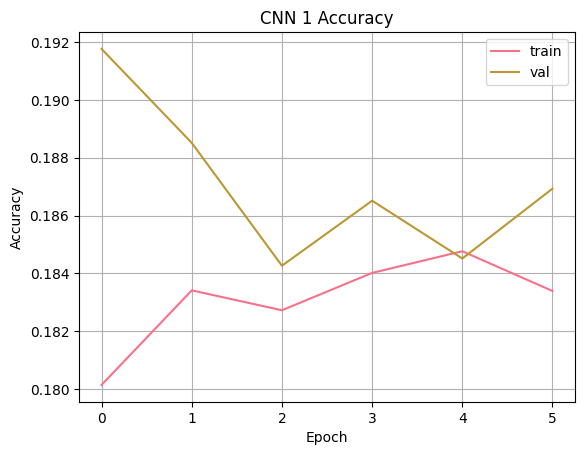

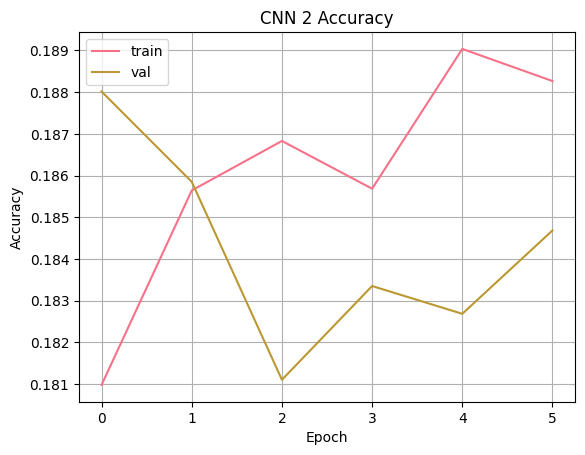

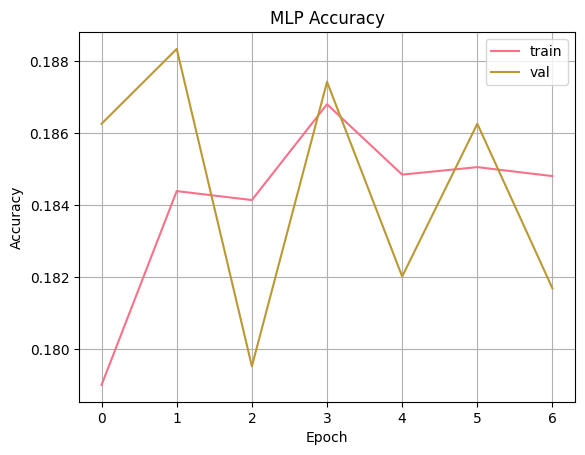

In [131]:
def evaluar(model, nombre):
    loss, acc = model.evaluate(test_generator)
    print(f"{nombre} - Test Accuracy: {acc:.4f} | Loss: {loss:.4f}")
    
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()
    

evaluar(cnn1, "CNN 1")
evaluar(cnn2, "CNN 2")
evaluar(mlp_model, "MLP")
plot_history(history_cnn1, "CNN 1")
plot_history(history_cnn2, "CNN 2")
plot_history(history_mlp, "MLP")